# 02 — Preprocessing

Turns the nine raw CSVs into fitted transformers and stratified train/test
splits under `data/processed/`. Every choice here is traceable to an
observation in notebook 01, and every choice is recorded in
`xai/schema.py` so the API applies exactly the same transform at inference
time. A preprocessing step that lives only in a notebook is a bug waiting for
deployment.

**Pipeline per dataset:** decode → sentinel zeros to NaN → drop leakage columns
→ impute → standardise → stratified 80:20 split.

In [1]:
import sys
import pathlib

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from xai import data, schema

FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
schema.MODELS.mkdir(parents=True, exist_ok=True)
schema.PROCESSED.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## 2.1 Categorical encoding

Only the CKD dataset ships strings. All ten of its categorical columns are
genuinely binary (`normal`/`abnormal`, `present`/`notpresent`, `yes`/`no`), so
they map to 0/1 with no information loss and no one-hot expansion.

**Ordinal features are deliberately left as single integer columns** rather
than one-hot encoded. Chest pain type, ST slope and thallium scan result are
nominal, so one-hot is the textbook choice — but it splits one clinical concept
across four SHAP bars, and "chest-pain-type-is-not-2 contributed +0.03" is not
a sentence a cardiologist can use. Keeping one column per concept means one
SHAP value per concept. We accept a small potential accuracy cost for
explanations that survive contact with a clinician; notebook 05 confirms the
models clear their baselines comfortably either way.

In [2]:
raw_ckd = pd.read_csv(schema.RAW / "kidney_disease.csv")
print("raw CKD categorical values (note the tab characters):")
for col in list(schema.get("kidney_disease").string_encodings)[:4]:
    print(f"  {col:<6} {raw_ckd[col].dropna().unique()[:5]}")

X_ckd, _ = data.load_raw("kidney_disease")
print("\nafter xai.data.load_raw (stripped, lower-cased, mapped to 0/1):")
print(X_ckd[["rbc", "pc", "htn", "dm"]].head(3).to_string())

raw CKD categorical values (note the tab characters):
  rbc    ['normal' 'abnormal']
  pc     ['normal' 'abnormal']
  pcc    ['notpresent' 'present']
  ba     ['notpresent' 'present']

after xai.data.load_raw (stripped, lower-cased, mapped to 0/1):
   rbc   pc  htn   dm
0  NaN  0.0  1.0  1.0
1  NaN  0.0  0.0  0.0
2  0.0  0.0  0.0  1.0


## 2.2 Sentinel zeros in the Pima dataset

Notebook 01 found five Pima columns using 0 as a missing marker. Below is what
that does to the reported statistics if you take the file at face value.

In [3]:
raw_pima = pd.read_csv(schema.RAW / "diabetes.csv")
X_pima, _ = data.load_raw("diabetes")
ds_pima = schema.get("diabetes")

comparison = pd.DataFrame(
    {
        "naive_mean": [raw_pima[c].mean() for c in ds_pima.zero_as_missing],
        "corrected_mean": [X_pima[c].mean() for c in ds_pima.zero_as_missing],
        "zeros": [int((raw_pima[c] == 0).sum()) for c in ds_pima.zero_as_missing],
        "pct_missing": [
            round(float((raw_pima[c] == 0).mean() * 100), 1)
            for c in ds_pima.zero_as_missing
        ],
    },
    index=[ds_pima.feature(c).label for c in ds_pima.zero_as_missing],
).round(2)
display(comparison)

print(
    "Taking the zeros literally understates mean serum insulin by "
    f"{comparison.loc['2-hour serum insulin', 'corrected_mean'] - comparison.loc['2-hour serum insulin', 'naive_mean']:.0f}"
    " mu U/mL — a whole cohort of patients with no measurable insulin."
)

,naive_mean,corrected_mean,zeros,pct_missing
Plasma glucose (2-hour OGTT),120.89,121.69,5,0.7
Diastolic blood pressure,69.11,72.64,35,4.6
Triceps skin fold thickness,20.54,29.15,227,29.6
2-hour serum insulin,79.80,155.55,374,48.7
Body mass index,31.99,32.46,11,1.4


Taking the zeros literally understates mean serum insulin by 76 mu U/mL — a whole cohort of patients with no measurable insulin.


## 2.3 Imputation strategy

| Dataset | Imputer | Justification |
|---|---|---|
| Heart Disease | median | 6 missing cells out of 3,939. Anything more elaborate is unjustifiable cost. |
| Heart Failure | median | No missing values; the imputer is present only so the fitted pipeline is uniform. |
| Pima Diabetes | median | Lab distributions are right-skewed (insulin especially), so the mean is dragged up by outliers. Median is the robust centre. |
| Chronic Kidney Disease | **KNN, k=5** | Up to 38% missing and demonstrably not-at-random. Filling 152 rows with one constant destroys the variance the model needs; nearest complete records preserve the joint distribution. |
| Breast Cancer (Wisconsin) | median | Nothing missing. Fitted for uniformity only. |
| Breast Cancer Recurrence | median | 10 cells across two columns, after repairing six Excel-mangled band labels. |
| Breast Cancer Survival | median | Nothing missing; three features. |
| Cervical Cancer | **KNN, k=5** | 12-14% missing across the contraceptive and STI blocks, missing because a patient declined to answer — informative, not random. Two columns at 91.7% missing are dropped rather than imputed. |
| Lung Cancer Surgery | median | Complete once 14 impossible FEV1 values (52-86 L) fall outside the declared range. |

Two datasets required a decision before imputation could even be considered.
**Cervical cancer** ships four outcome columns recorded at the same visit; three
are dropped as parallel measurements of the target, and two constant columns are
dropped because zero variance carries zero information.

### One rule for impossible values

Every feature declares a plausible clinical range in `xai/schema.py`. That range
is what the API validates incoming requests against, and it is *also* the
threshold for cleaning the training data: any value outside it becomes missing.

Using one number for both is the point. A validator that rejects a value the
model trained on, or a model that trains on a value the validator would reject,
is incoherent in opposite directions — and both were true here before this rule
existed. It replaces what had been a per-dataset list of impossible ceilings.

Across all nine datasets the rule touches **19 cells**:

| Dataset | Feature | Values dropped | Why they cannot be real |
|---|---|---|---|
| Pima Diabetes | BloodPressure | 24, 30, 30, 38 mm Hg | diastolic that low is shock, not an outpatient |
| Chronic Kidney Disease | sod | 4.5 mEq/L | human serum sodium is 135-145; 4.5 is not survivable |
| Lung Cancer Surgery | PRE5 (FEV1) | 14 values, 52-86 L | no lung holds 86 litres |

Sentinel zeros are still handled separately, because 0 there is a *code* for
"not recorded" rather than an out-of-range measurement.

The imputer is fitted **on the training split only** and then applied to the
test split. Fitting on all rows first would leak test-set distribution into
training and inflate every metric in notebook 05.

In [4]:
skew = X_pima[list(ds_pima.zero_as_missing)].skew().round(2)
print("Pima skewness of the affected columns (0 = symmetric):")
print(skew.to_string())
print("\nRight-skewed columns confirm median over mean.")

Pima skewness of the affected columns (0 = symmetric):
Glucose          0.53
BloodPressure    0.33
SkinThickness    0.69
Insulin          2.17
BMI              0.59

Right-skewed columns confirm median over mean.


## 2.4 Scaling

`StandardScaler` on every feature. The trees do not need it, but:

1. Logistic Regression needs it to converge sensibly and to make coefficients
   comparable in magnitude.
2. **LIME needs it.** LIME explains a prediction by sampling a synthetic
   neighbourhood around the patient. On unscaled clinical data, platelet count
   (25,000–850,000) would dominate the distance metric and swamp ejection
   fraction (10–80), so the "similar patients" LIME reasons about would differ
   only in platelets. One shared scaled space for all three models also means
   one comparable SHAP feature space.

## 2.5 Stratified 80:20 split

Stratified on the outcome. Heart failure is 32% positive; with 299 rows an
unstratified split can hand back a test set whose prevalence is several points
off the cohort's, and every metric then measures the split rather than the
model. `random_state=42` throughout for reproducibility.

In [5]:
records = []
for slug, ds in schema.DATASETS.items():
    bundle = data.prepare(slug)
    written = data.save_processed(slug, bundle)
    joblib.dump(bundle["pre"], schema.MODELS / f"{slug}_preprocessor.pkl")

    X_train, X_test = bundle["X_train"], bundle["X_test"]
    y_train, y_test = bundle["y_train"], bundle["y_test"]

    assert not X_train.isna().any().any(), f"{slug}: NaN survived imputation"
    assert not X_test.isna().any().any(), f"{slug}: NaN survived imputation (test)"
    assert list(X_train.columns) == ds.feature_names, f"{slug}: column order drift"
    # Scaler fitted on train, so train means are ~0 and SDs ~1.
    assert np.allclose(X_train.mean(), 0, atol=1e-8), f"{slug}: train not centred"

    records.append(
        {
            "dataset": ds.title,
            "slug": slug,
            "features": len(ds.feature_names),
            "dropped": ", ".join(ds.drop_columns) or "—",
            "imputer": ds.imputer,
            "train_n": len(X_train),
            "test_n": len(X_test),
            "train_pos_rate": round(float(y_train.mean()), 3),
            "test_pos_rate": round(float(y_test.mean()), 3),
        }
    )
    print(f"{slug:<16} -> {', '.join(written)}, {slug}_preprocessor.pkl")

splits = pd.DataFrame(records)
display(splits)

print("Prevalence preserved across splits (max drift "
      f"{(splits.train_pos_rate - splits.test_pos_rate).abs().max():.3f}).")

heart_disease    -> heart_disease_x_train.csv, heart_disease_x_test.csv, heart_disease_x_test_raw.csv, heart_disease_preprocessor.pkl
heart_failure    -> heart_failure_x_train.csv, heart_failure_x_test.csv, heart_failure_x_test_raw.csv, heart_failure_preprocessor.pkl
diabetes         -> diabetes_x_train.csv, diabetes_x_test.csv, diabetes_x_test_raw.csv, diabetes_preprocessor.pkl


kidney_disease   -> kidney_disease_x_train.csv, kidney_disease_x_test.csv, kidney_disease_x_test_raw.csv, kidney_disease_preprocessor.pkl


breast_cancer    -> breast_cancer_x_train.csv, breast_cancer_x_test.csv, breast_cancer_x_test_raw.csv, breast_cancer_preprocessor.pkl
breast_cancer_recurrence -> breast_cancer_recurrence_x_train.csv, breast_cancer_recurrence_x_test.csv, breast_cancer_recurrence_x_test_raw.csv, breast_cancer_recurrence_preprocessor.pkl


breast_cancer_survival -> breast_cancer_survival_x_train.csv, breast_cancer_survival_x_test.csv, breast_cancer_survival_x_test_raw.csv, breast_cancer_survival_preprocessor.pkl


cervical_cancer  -> cervical_cancer_x_train.csv, cervical_cancer_x_test.csv, cervical_cancer_x_test_raw.csv, cervical_cancer_preprocessor.pkl
lung_cancer_surgery -> lung_cancer_surgery_x_train.csv, lung_cancer_surgery_x_test.csv, lung_cancer_surgery_x_test_raw.csv, lung_cancer_surgery_preprocessor.pkl


,dataset,slug,features,dropped,imputer,train_n,test_n,train_pos_rate,test_pos_rate
0,Heart Disease (Cleveland),heart_disease,13,—,median,242,61,0.459,0.459
1,Heart Failure Clinical Records,heart_failure,11,time,median,239,60,0.322,0.317
2,Pima Indians Diabetes,diabetes,8,—,median,614,154,0.349,0.351
3,Chronic Kidney Disease,kidney_disease,24,—,knn,320,80,0.625,0.625
4,Breast Cancer Wisconsin (Diagnostic),breast_cancer,30,—,median,455,114,0.374,0.368
5,Breast Cancer Recurrence (Ljubljana),breast_cancer_recurrence,9,—,median,228,58,0.298,0.293
6,Breast Cancer Surgical Survival (Haberman),breast_cancer_survival,3,—,median,244,62,0.266,0.258
7,Cervical Cancer (Risk Factors),cervical_cancer,28,"STDs: Time since first diagnosis, STDs: Time s...",knn,686,172,0.064,0.064
8,Lung Cancer Thoracic Surgery,lung_cancer_surgery,16,—,median,376,94,0.149,0.149


Prevalence preserved across splits (max drift 0.008).


## 2.6 Did scaling and imputation distort the distributions?

A sanity check worth doing explicitly: imputation should fill gaps without
moving the centre of the distribution. Below, raw vs. processed for the two
features with the heaviest imputation load in the project.

2-hour serum insulin: observed median 125.0, imputed median 125.0


Red blood cell count: observed median 4.8, imputed median 4.8


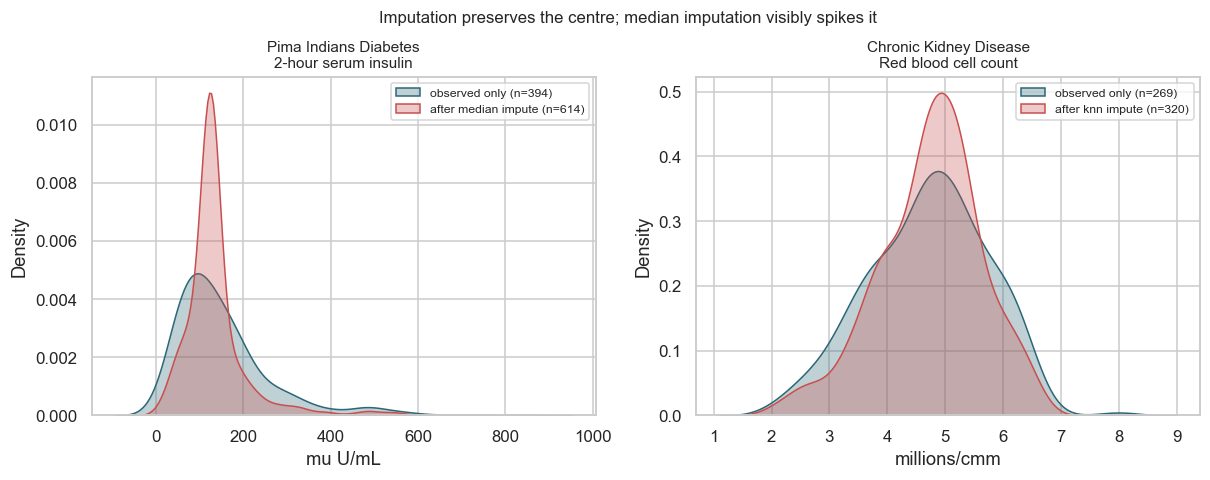

In [6]:
checks = [("diabetes", "Insulin"), ("kidney_disease", "rbcc")]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (slug, feat) in zip(axes, checks):
    ds = schema.get(slug)
    X_raw, _ = data.load_raw(slug)
    bundle = data.prepare(slug)
    imputed = pd.DataFrame(
        bundle["pre"].named_steps["columns"].transform(bundle["X_train_raw"]),
        columns=ds.feature_names,
    )[feat]
    observed = X_raw[feat].dropna()

    sns.kdeplot(observed, ax=ax, label=f"observed only (n={len(observed)})",
                fill=True, alpha=0.3, color="#2b6777", warn_singular=False)
    sns.kdeplot(imputed, ax=ax, label=f"after {ds.imputer} impute (n={len(imputed)})",
                fill=True, alpha=0.3, color="#c94f4f", warn_singular=False)
    ax.set_title(f"{ds.title}\n{ds.feature(feat).label}", fontsize=10)
    ax.set_xlabel(ds.feature(feat).unit or "")
    ax.legend(fontsize=8)
    print(f"{ds.feature(feat).label}: observed median {observed.median():.1f}, "
          f"imputed median {imputed.median():.1f}")

plt.suptitle("Imputation preserves the centre; median imputation visibly spikes it",
             y=1.03, fontsize=11)
plt.savefig(FIGURES / "02_imputation_effect.png")
plt.show()

The median-imputed insulin curve shows the expected artefact: a sharp spike at
the median where 374 identical values were inserted. That is the honest cost of
median imputation on a column that is half missing, and it is precisely why CKD
uses KNN instead — the KNN-imputed red cell count keeps a smooth shape.

This artefact has an explainability consequence worth flagging in the report:
for patients whose insulin was imputed, any SHAP attribution to insulin partly
reflects our imputation choice rather than the patient. The API therefore
requires the caller to supply real values within clinical range rather than
silently accepting zeros.

## 2.7 Does the declared schema match the data?

`xai/schema.py` declares every feature's plausible range and, for categoricals,
the exact set of permitted values. Those declarations become the API's validator
and the dashboard's form, so a declaration that disagrees with the data is a bug
with two symptoms: the form offers a value the model has never seen, and the API
accepts it and extrapolates silently.

This is checked rather than trusted. It has already caught one real case — the
lung-cancer form offered `DGN7`, a category absent from all 470 records.

In [7]:
offered_but_unseen, out_of_declared_range = [], []

for slug, ds in schema.DATASETS.items():
    X, _ = data.load_raw(slug)
    for feat in ds.features:
        col = X[feat.name].dropna()
        if feat.choices:
            seen = set(np.round(col.unique(), 3))
            for value in sorted(feat.choices):
                if value not in seen:
                    offered_but_unseen.append(
                        {"dataset": slug, "feature": feat.name,
                         "label": feat.label, "offered": value,
                         "shown_as": feat.choices[value]}
                    )
        if len(col):
            below, above = int((col < feat.lo).sum()), int((col > feat.hi).sum())
            if below or above:
                out_of_declared_range.append(
                    {"dataset": slug, "feature": feat.name,
                     "declared": f"{feat.lo}–{feat.hi}",
                     "actual": f"{col.min():g}–{col.max():g}",
                     "rows_below": below, "rows_above": above}
                )

print(f"categorical options offered but never observed: {len(offered_but_unseen)}")
for r in offered_but_unseen:
    print(f"   {r['dataset']}.{r['feature']} offers {r['offered']} ({r['shown_as']})")

print(f"\nfeatures with data outside the declared range: {len(out_of_declared_range)}")
for r in out_of_declared_range:
    print(f"   {r['dataset']}.{r['feature']}: declared {r['declared']}, "
          f"actual {r['actual']} ({r['rows_below']} below, {r['rows_above']} above)")

assert not offered_but_unseen, (
    "the form would offer a category the model never saw — remove it from "
    "`choices` in the schema, or confirm the data really contains it"
)
print("\nSchema and data agree: every offered category occurs in the data.")

categorical options offered but never observed: 0

features with data outside the declared range: 0

Schema and data agree: every offered category occurs in the data.


The out-of-range count is now expected to be **zero**: `load_raw` converts those
values to missing, so by the time the check runs there is nothing left outside
the declared bounds. A non-zero count here would mean the cleaning rule and the
declared range had drifted apart.

A declared range is deliberately a little wider than the observed one — it has to
accept a plausible future patient, not just the ones in this cohort. Widening it
is a considered act: `PRE5`'s upper bound is 9 L rather than 7 precisely so one
real 8.56 L record survives.

## 2.8 Artefacts produced

In [8]:
print("data/processed/")
for path in sorted(schema.PROCESSED.glob("*.csv")):
    frame = pd.read_csv(path)
    print(f"  {path.name:<38} {frame.shape[0]:>4} rows x {frame.shape[1]:>2} cols")

print("\nmodels/")
for path in sorted(schema.MODELS.glob("*_preprocessor.pkl")):
    print(f"  {path.name}")

splits.to_json(ROOT / "results" / "02_splits.json", orient="records", indent=2)
print("\nwrote results/02_splits.json")
print("Next: 03_model_training.ipynb")

data/processed/
  breast_cancer_recurrence_x_test.csv      58 rows x 10 cols
  breast_cancer_recurrence_x_test_raw.csv   58 rows x  9 cols
  breast_cancer_recurrence_x_train.csv    228 rows x 10 cols
  breast_cancer_survival_x_test.csv        62 rows x  4 cols
  breast_cancer_survival_x_test_raw.csv    62 rows x  3 cols
  breast_cancer_survival_x_train.csv      244 rows x  4 cols
  breast_cancer_x_test.csv                114 rows x 31 cols
  breast_cancer_x_test_raw.csv            114 rows x 30 cols
  breast_cancer_x_train.csv               455 rows x 31 cols
  cervical_cancer_x_test.csv              172 rows x 29 cols
  cervical_cancer_x_test_raw.csv          172 rows x 28 cols
  cervical_cancer_x_train.csv             686 rows x 29 cols
  diabetes_x_test.csv                     154 rows x  9 cols
  diabetes_x_test_raw.csv                 154 rows x  8 cols
  diabetes_x_train.csv                    614 rows x  9 cols
  heart_disease_x_test.csv                 61 rows x 14 cols
  heart